In [ ]:
 os
print("Hello Riya")import

Hello Diksha


In [ ]:
import sys
print(sys.executable)

c:\Users\DIKSHA RAI\Desktop\SkinDiseaseDiagnosis\venv\Scripts\python.exe


In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

In [20]:
dataset_path = "../dataset"

print(os.listdir(dataset_path))

['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [21]:
for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        print(folder, ":", len(os.listdir(folder_path)))

1. Eczema 1677 : 1677
10. Warts Molluscum and other Viral Infections - 2103 : 2103
2. Melanoma 15.75k : 3140
3. Atopic Dermatitis - 1.25k : 1257
4. Basal Cell Carcinoma (BCC) 3323 : 3323
5. Melanocytic Nevi (NV) - 7970 : 7970
6. Benign Keratosis-like Lesions (BKL) 2624 : 2079
7. Psoriasis pictures Lichen Planus and related diseases - 2k : 2055
8. Seborrheic Keratoses and other Benign Tumors - 1.8k : 1847
9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k : 1702


In [22]:
data = []

for folder in os.listdir(dataset_path):
    folder_path = os.path.join(dataset_path, folder)

    if os.path.isdir(folder_path):
        count = len(os.listdir(folder_path))
        data.append([folder, count])

df = pd.DataFrame(data, columns=["Disease", "Images"])
df

,Disease,Images
0,1. Eczema 1677,1677
1,10. Warts Molluscum and other Viral Infections...,2103
2,2. Melanoma 15.75k,3140
3,3. Atopic Dermatitis - 1.25k,1257
4,4. Basal Cell Carcinoma (BCC) 3323,3323
5,5. Melanocytic Nevi (NV) - 7970,7970
6,6. Benign Keratosis-like Lesions (BKL) 2624,2079
7,7. Psoriasis pictures Lichen Planus and relate...,2055
8,8. Seborrheic Keratoses and other Benign Tumor...,1847
9,9. Tinea Ringworm Candidiasis and other Fungal...,1702


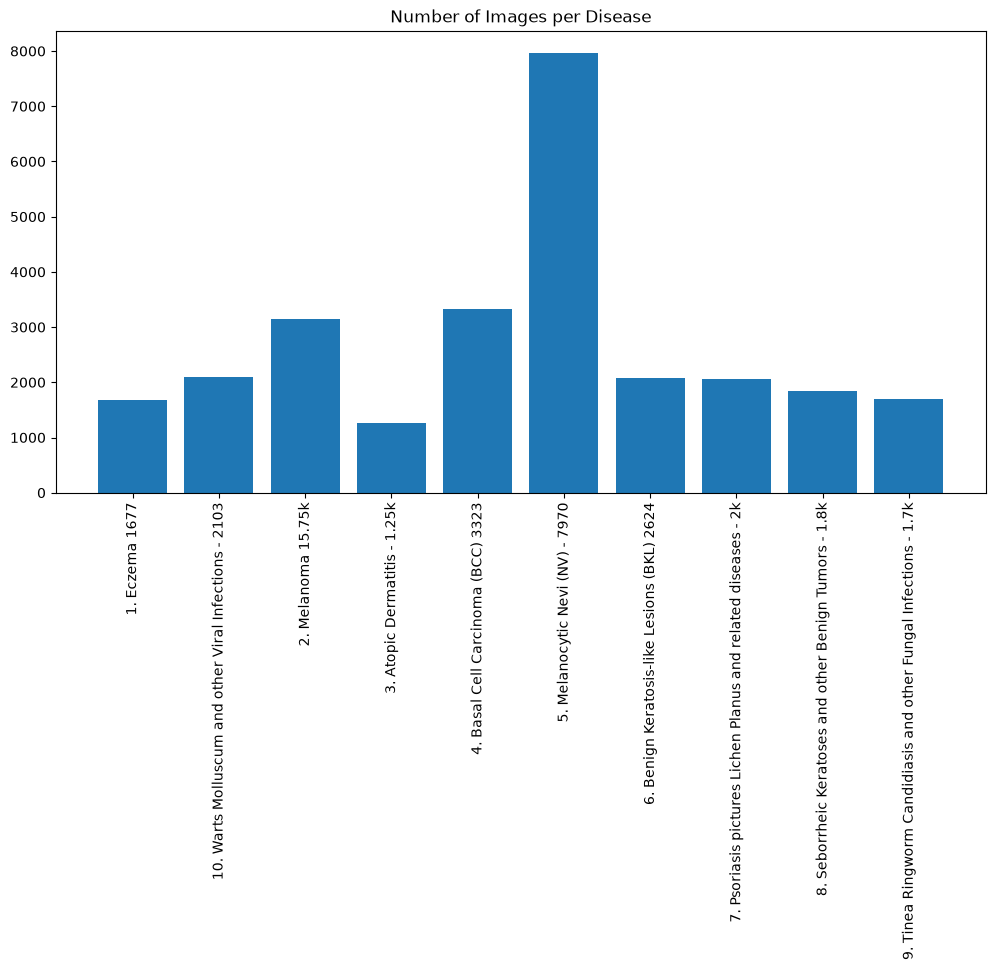

In [23]:
plt.figure(figsize=(12,6))
plt.bar(df["Disease"], df["Images"])
plt.xticks(rotation=90)
plt.title("Number of Images per Disease")
plt.show()

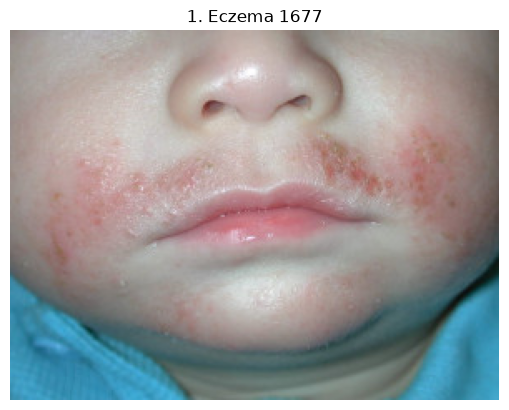

In [10]:
sample_folder = os.listdir(dataset_path)[0]

folder_path = os.path.join(dataset_path, sample_folder)

sample_image = os.listdir(folder_path)[0]

image_path = os.path.join(folder_path, sample_image)

img = Image.open(image_path)

plt.imshow(img)
plt.title(sample_folder)
plt.axis("off")
plt.show()

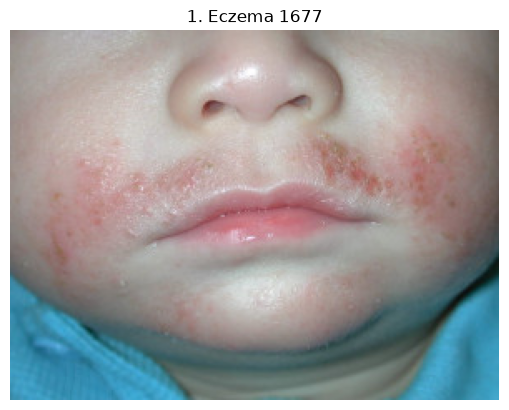

Image Size: (294, 222)


In [24]:
sample_folder = os.listdir(dataset_path)[0]

folder_path = os.path.join(dataset_path, sample_folder)

sample_image = os.listdir(folder_path)[0]

image_path = os.path.join(folder_path, sample_image)

img = Image.open(image_path)

plt.imshow(img)
plt.title(sample_folder)
plt.axis("off")
plt.show()

print("Image Size:", img.size)

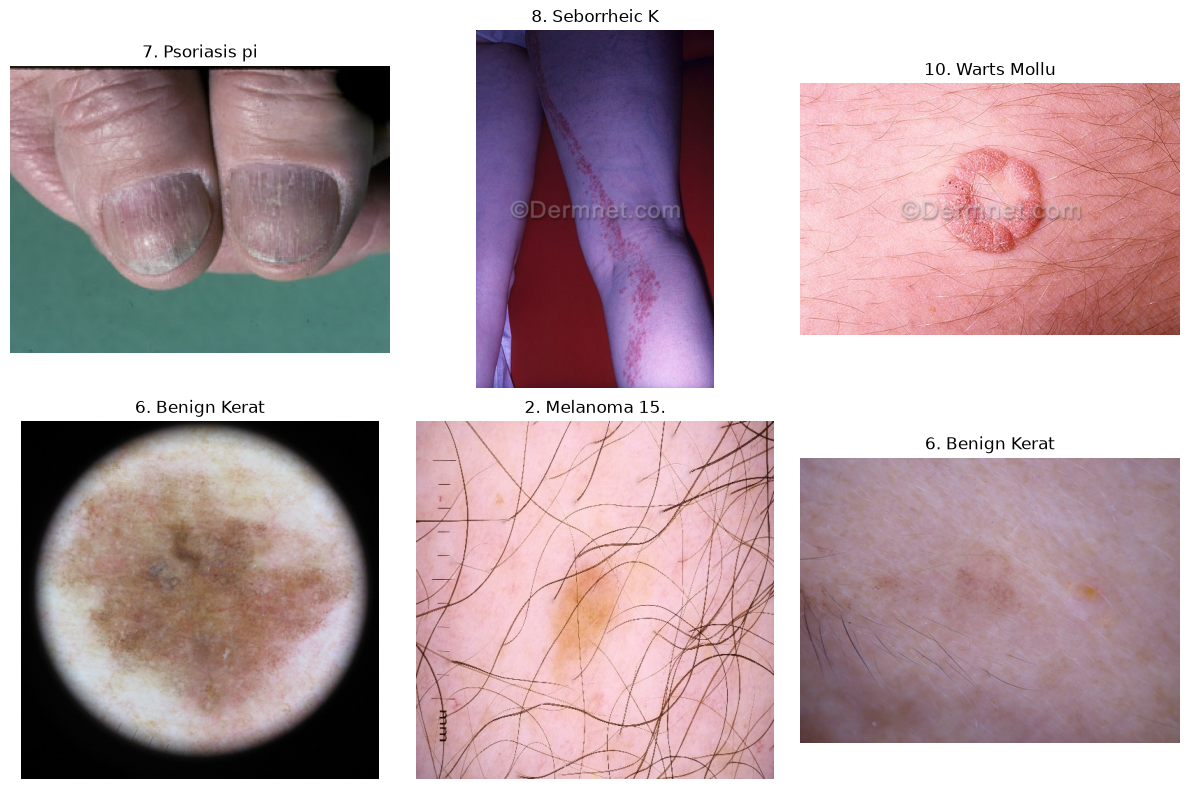

In [12]:
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for ax in axes.flat:
    disease = np.random.choice(os.listdir(dataset_path))

    disease_path = os.path.join(dataset_path, disease)

    image_name = np.random.choice(os.listdir(disease_path))

    image_path = os.path.join(disease_path, image_name)

    img = Image.open(image_path)

    ax.imshow(img)
    ax.set_title(disease[:15])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [25]:
import sys
print(sys.executable)

c:\Users\DIKSHA RAI\Desktop\SkinDiseaseDiagnosis\venv\Scripts\python.exe


In [26]:
import tensorflow as tf

print(tf.__version__)

2.21.0


In [27]:
from tensorflow.keras.preprocessing import image_dataset_from_directory

dataset_path = "../dataset"

train_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 27153 files belonging to 10 classes.
Using 21723 files for training.


In [28]:
val_ds = image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(224,224),
    batch_size=32
)

Found 27153 files belonging to 10 classes.
Using 5430 files for validation.


In [30]:
class_names = train_ds.class_names

print(class_names)

['1. Eczema 1677', '10. Warts Molluscum and other Viral Infections - 2103', '2. Melanoma 15.75k', '3. Atopic Dermatitis - 1.25k', '4. Basal Cell Carcinoma (BCC) 3323', '5. Melanocytic Nevi (NV) - 7970', '6. Benign Keratosis-like Lesions (BKL) 2624', '7. Psoriasis pictures Lichen Planus and related diseases - 2k', '8. Seborrheic Keratoses and other Benign Tumors - 1.8k', '9. Tinea Ringworm Candidiasis and other Fungal Infections - 1.7k']


In [31]:
from tensorflow.keras import layers

normalization_layer = layers.Rescaling(1./255)

train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y))

In [32]:
from tensorflow.keras import models, layers

model = models.Sequential([

    layers.Input(shape=(224,224,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),

    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,170,250 (42.61 MB)

 Trainable params: 11,170,250 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import models, layers

base_model = MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(128, activation="relu"),
    layers.Dense(10, activation="softmax")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,423,242 (9.24 MB)

 Trainable params: 165,258 (645.54 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [34]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 875s 1s/step - accuracy: 0.5002 - loss: 1.3645 - val_accuracy: 0.5567 - val_loss: 1.1954
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 1216s 2s/step - accuracy: 0.6021 - loss: 1.0524 - val_accuracy: 0.5720 - val_loss: 1.1388
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 1977s 3s/step - accuracy: 0.6501 - loss: 0.9374 - val_accuracy: 0.6052 - val_loss: 1.1152
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 715s 1s/step - accuracy: 0.6907 - loss: 0.8270 - val_accuracy: 0.6306 - val_loss: 1.0650
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 691s 1s/step - accuracy: 0.7382 - loss: 0.7114 - val_accuracy: 0.6109 - val_loss: 1.2134


In [37]:
model.save("../model/mobilenet_skin_model.keras")

In [36]:
loss, acc = model.evaluate(val_ds)

print("Validation Accuracy:", acc * 100)

170/170 ━━━━━━━━━━━━━━━━━━━━ 94s 550ms/step - accuracy: 0.6109 - loss: 1.2134
Validation Accuracy: 61.08655333518982


In [38]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [41]:
history = model.fit(
    train_ds,1
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 552s 808ms/step - accuracy: 0.7857 - loss: 0.5850 - val_accuracy: 0.6265 - val_loss: 1.2608
Epoch 2/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 534s 786ms/step - accuracy: 0.8271 - loss: 0.4874 - val_accuracy: 0.6379 - val_loss: 1.3948
Epoch 3/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 532s 783ms/step - accuracy: 0.8622 - loss: 0.3984 - val_accuracy: 0.6339 - val_loss: 1.6353
Epoch 4/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 530s 780ms/step - accuracy: 0.8852 - loss: 0.3323 - val_accuracy: 0.6354 - val_loss: 1.8250
Epoch 5/5
679/679 ━━━━━━━━━━━━━━━━━━━━ 2282s 3s/step - accuracy: 0.9147 - loss: 0.2546 - val_accuracy: 0.6298 - val_loss: 2.2244


In [42]:
model.save("../model/skin_disease_model.keras")

In [43]:
loss, accuracy = model.evaluate(val_ds)

print("Validation Accuracy:", accuracy)

170/170 ━━━━━━━━━━━━━━━━━━━━ 38s 220ms/step - accuracy: 0.6298 - loss: 2.2244
Validation Accuracy: 0.6298342347145081


In [44]:
from tensorflow.keras.models import load_model

saved_model = load_model("../model/skin_disease_model.keras")

In [45]:
model.save("../model/skin_disease_model.keras")